In [2]:
from alc import *
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import os
from labos.Labo1 import transpuesta
from labos.Labo5 import calculaQR
from labos.Labo8 import svd_reducida


In [3]:
actualPath = os.getcwd()
basePath = os.path.join(actualPath, "cats_and_dogs")
Xt, Yt, Xv, Yv = cargarDataset(basePath)

## Analisis

### Matriz de confusion de metodos

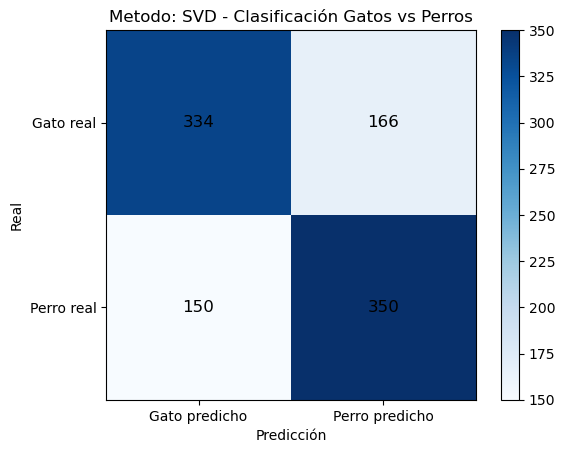

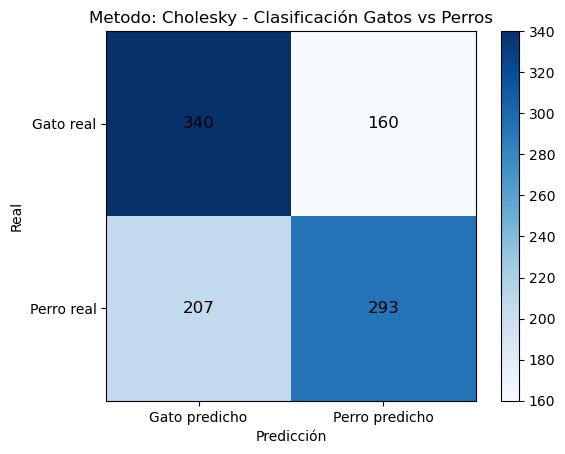

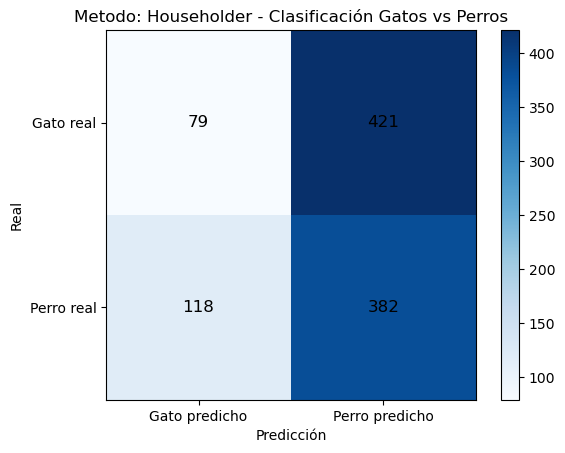

In [ ]:
nombres_metodos = ["SVD", "Cholesky", "Householder"]

# Codigo de ploteo
W_SVD= np.load("/home/Estudiante/Escritorio/ALC/ALC-main/W_svd.npy")
W_CHOLESKY = np.load("/home/Estudiante/Escritorio/ALC/ALC-main/W_e_primitivas.npy")
# W_GS =np.load("../W_e_primitivas.npy")
W_HH =np.load("/home/Estudiante/Escritorio/ALC/ALC-main/W_householder.npy")
        
r_SVD = transpuesta( W_SVD @ Xv)
r_CHOLESKY = transpuesta( W_CHOLESKY @ Xv)
r_HH = transpuesta( W_HH @ Xv)
# Agregar las 2 W faltantes

# Lista para procesar cada r de los metodos para así crear la matriz de confusion
lista_r = list()
lista_r.append(r_SVD)
lista_r.append(r_CHOLESKY)
lista_r.append(r_HH)

# Listas para luego usar en la tabla de comparativa
aciertoGatos = list()
aciertoPerros = list()
precisionModelo = list()

# Convertir las predicciones : elegimos el índice del valor máximo

for r in lista_r:
    predicciones = np.argmax(r, axis=1)
    etiquetas_reales = np.argmax(Yv, axis=1)


    # Crear matriz de confusión
    
    matriz_conf = confusion_matrix(etiquetas_reales, predicciones)

    # Agrego aciertos para luego crear la tabla
    aciertoGatos.append(matriz_conf[0,0]/5) 
    aciertoPerros.append(matriz_conf[1,1]/5)
    precisionModelo.append((matriz_conf[0,0] + matriz_conf[1,1])/10)


    plt.imshow(matriz_conf, cmap='Blues')
    plt.colorbar()

    # Mostrar los valores dentro de cada celda
    for i in range(matriz_conf.shape[0]):
        for j in range(matriz_conf.shape[1]):
            plt.text(j, i, matriz_conf[i, j],
                     ha='center', va='center', color='black', fontsize=12)


    # Etiquetas de ejes
    plt.xticks([0, 1], ['Gato predicho', 'Perro predicho'])
    plt.yticks([0, 1], ['Gato real', 'Perro real'])

    plt.xlabel('Predicción')
    plt.ylabel('Real')

    metodo = nombres_metodos.pop(0)  # ACÁ, campeón

    plt.title(f"Metodo: {metodo} - Clasificación Gatos vs Perros")
    plt.show()


### Tabla comparativa de resultados de cada metodologia

In [9]:
data = {
    "Tasa de aciertos (gatos)": aciertoGatos,
    "Tasa de aciertos (perros)": aciertoPerros,
    "Acierto total": precisionModelo
}


metodos = [
    "SVD",
    "Cholesky",
    "Householder"
]

df = pd.DataFrame(data, index=metodos)

print("\n=== Comparación de Métodos ===\n")
print(df.to_string())



=== Comparación de Métodos ===

             Tasa de aciertos (gatos)  Tasa de aciertos (perros)  Acierto total
SVD                              66.8                       70.0           68.4
Cholesky                         68.0                       58.6           63.3
Householder                      15.8                       76.4           46.1


## Sintesis Final

Una vez finalizadas nuestras experimentaciones con las múltiples metodologías, vamos a analizar cuáles son los más adecuados usando como parametros de evaluacion: La complejidad, la precision de aciertos y el equilibrio de las predicciones.

## Resultados

El método de descomposición de valores singulares obtuvo una tasa de aciertos de gatos de 66,8 % , de perros de 70% y una precisión total de 68,4%. Se puede observar que la tasa de aciertos entre gatos y perros es similar lo que es una buena señal ya que nos muestra una matriz de entrenamiento que conserva equilibrio en los resultados. Es decir, no existen sesgos.

Con el método de Cholesky, el acierto de gatos fue de 68% , de perros 58.6%, y un acierto total de 63,3%. En este caso hay una diferencia mayor entre las dos clases, teniendo una tendencia a pronosticar gatos lo cual nos hace preguntarnos si la alta tasa de aciertos sobre gatos se debe a un buen entrenamiento o a esta tendencia.

Con respecto al metodo de Gram schmidt, el acierto de gatos fue de 68% , de perros 58.6%, y un acierto total de 63,3%. Podemos observar que los resultados en la prediccion son identicos al metodo de Cholesky.

Por ultimo,con el metodo de House Holder obtuvimos una tasa de acierto del 15% en gatos,de 76.4 % en perros y un 46,1% total.Se ve una clara tendencia a pronosticar perro,pudiendose ver que el 80% de las imagenes las cataloga como perros.


## Analisis de complejidad
 
Todos los metodos tienen una complejidad O(n³),sin embargo el metodo de Cholesky resulto ser el mas rapido,creemos que esto se debe a que la constante es mucho mas chica que en los otros metodos,luego siguen los metodos por QR y por ultimo el metodo mas pesado es el de SVD,probablemente por tener una mayor cantidad de operaciones que los otros dos.

## Conclusion
Nuestra conclusion es que el modelo entrenado con la descomposicion de valores singulares es el mejor.Este metodo muestra un balance entre efectividad y equilibrio de resultados.Sin embargo,es la mas costosa por lo que en una situacion donde el costo sea algo a tener en cuenta puede ser mejor el metodo de descomposicion de cholesky.Claramente el peor metodo fue el de House Holder,puesto que creemos que la tasa de efectividad(tanto total como de perros) se debe a que el 80% de las veces predijo perro y la mitad de las imagenes de valuacion son perros.

Entonces,en un escenario donde el costo no sea algo a tener en cuenta el mejor metodo es el de SVD mientras que si el costo es importante puede ser el metodo de Cholesky la mejor opcion.
    